# Notebook 02 — Stock Performance by Company

## Public sentiment - financial confidence evaluation

This Notebook analyses the financial performance of selected relevant companies in the industry to gauge public and investor sentiment in the beauty industry.

## Methodology

**Approach:**
Stock price data was downloaded via yfinance for 7 companies covering 2022–2025.
All series are normalised to an index of 100 at the first trading day of 2022 
to enable cross-company comparison of relative performance, independent of 
absolute share price differences.

**Companies & Tickers:**
| Company | Ticker | Exchange |
|---------|--------|----------|
| Estée Lauder | EL | NYSE |
| LVMH | LVMUY | OTC |
| L'Oréal | LRLCY | OTC |
| Shiseido | 4911.T | TSE |
| Kosé | 4922.T | TSE |
| Unilever | UL | NYSE |
| Kao | 4452.T | TSE |

**Limitations:**
- Stock prices reflect whole-group investor sentiment, not beauty segment performance
- Time period of only 4 years may not be wholly reflective of each company's historical performance
- L'Oréal, Shiseido, ELC, Kosé are pure or near-pure beauty plays — most reliable proxies
- LVMH: Fashion & Leather Goods ~50% of revenue — beauty signal diluted
- Unilever: Beauty & Wellbeing ~20% of group revenue — heavily diluted
- Kao: Cosmetics ~15% of group revenue — least reliable proxy
- OTC-listed ADRs (LVMUY, LRLCY) may exhibit lower liquidity and slight price divergence from primary listings

In [2]:
# ── Setup ─────────────────────────────────────────────────
import sys
import pandas as pd
import os
sys.path.append(os.path.abspath(".."))

import importlib
import src.helpers
importlib.reload(src.helpers)
from src.helpers import *

import yfinance as yf

# ── Date range derived from revenue data ───────────────────
df_master = pd.read_csv("../data/processed/master_revenue.csv")
start_date = f"{df_master['Year'].min()}-01-01"
end_date   = f"{df_master['Year'].max()}-12-31"

print("Setup complete ✓")

Setup complete ✓


In [3]:
# ── Define companies & tickers ─────────────────────────────
companies = {
    "Estée Lauder": "EL",
    "LVMH":         "LVMUY",
    "L'Oréal":      "LRLCY",
    "Shiseido":     "4911.T",
    "Kosé":         "4922.T",
    "Unilever":     "UL",
    "Kao":          "4452.T",
}

# ── Download price data ────────────────────────────────────
close_dict = {}
for name, symbol in companies.items():
    df_ticker = yf.download(symbol, start=start_date, end=end_date,
                            auto_adjust=True, progress=False)
    if not df_ticker.empty:
        close_dict[name] = df_ticker["Close"].squeeze()
        print(f"{name} ({symbol}): {len(df_ticker)} rows ✓")
    else:
        print(f"{name} ({symbol}): FAILED ✗")

close = pd.DataFrame(close_dict)
close = close.interpolate(method="linear").ffill().bfill()

normalised = close.div(close.apply(lambda x: x.dropna().iloc[0])) * 100

print("NaN check:\n", normalised.isna().sum())

Estée Lauder (EL): 1002 rows ✓
LVMH (LVMUY): 1002 rows ✓
L'Oréal (LRLCY): 1002 rows ✓
Shiseido (4911.T): 978 rows ✓
Kosé (4922.T): 978 rows ✓
Unilever (UL): 1002 rows ✓
Kao (4452.T): 978 rows ✓
NaN check:
 Estée Lauder    0
LVMH            0
L'Oréal         0
Shiseido        0
Kosé            0
Unilever        0
Kao             0
dtype: int64


Saved: c:\Users\stanl\OneDrive\Desktop\VSCode_Projects\1. Luxury_DataAnalysis\outputs\charts\02_stock_performance.png


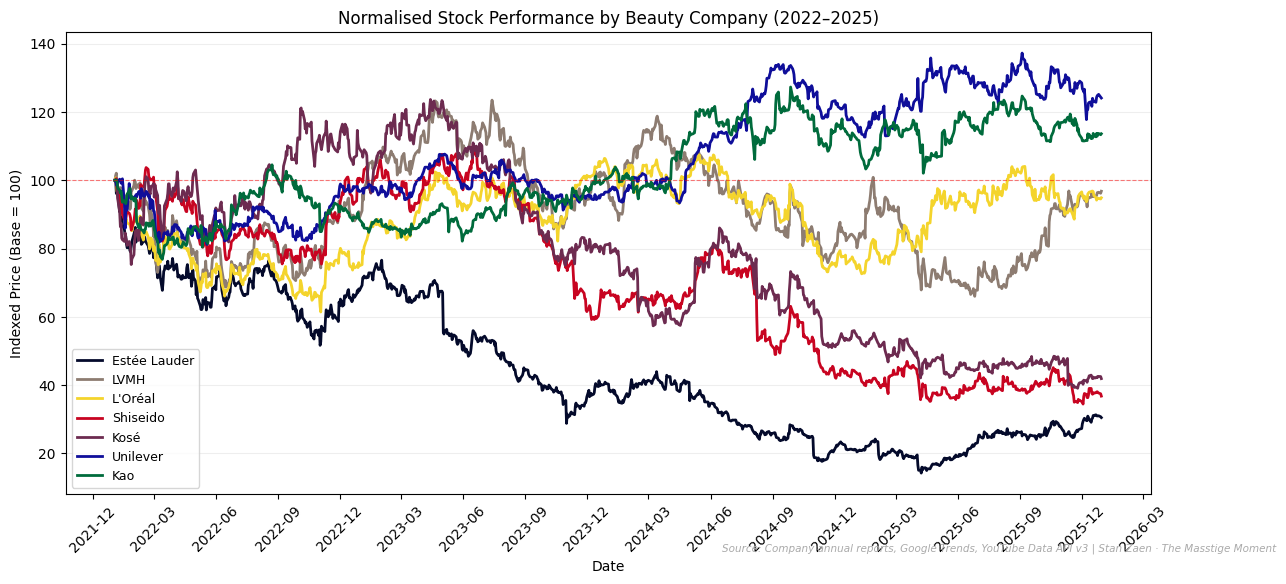

In [4]:
# ── Chart: Normalised stock performance by company ─────────
fig, ax = plt.subplots(figsize=FIG_DOUBLE)
apply_grid(ax)

for name in normalised.columns:
    ax.plot(normalised.index, normalised[name],
            label=name,
            color=COMPANY_COLOURS[name],
            linewidth=2)

ax.axhline(100, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Normalised Stock Performance by Beauty Company (2022–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Price (Base = 100)")
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

save_chart(fig, "02_stock_performance.png")
plt.show()

In [5]:
# ── Dynamic Key Observations ─────────────────────────────
final_vals = normalised.iloc[-1].sort_values()
start_date = normalised.index[0].strftime("%Y-%m")
end_date   = normalised.index[-1].strftime("%Y-%m")

lines = "\n".join([
    f"- **{name}**: {val:.1f} (base 100 at {start_date})"
    for name, val in final_vals.items()
])

best  = final_vals.idxmax()
worst = final_vals.idxmin()

obs = f"""
### Key Observations

Stock performance diverges sharply by geography and company ({start_date}–{end_date}).

{lines}

- **{worst}** is the standout underperformer ({final_vals[worst]:.1f})
- **{best}** showed the strongest relative resilience ({final_vals[best]:.1f})

⚠️ Stock Price Limitations
- Following worth bearing again:
 -> L'Oréal, Shiseido, ELC, Kosé: pure/near-pure beauty — most reliable proxies
 -> LVMH: Fashion & Leather Goods ~50% of revenue — beauty signal diluted
 -> Unilever: Beauty & Wellbeing ~20% of group — heavily diluted
 -> Kao: Cosmetics ~15% of group — least reliable proxy

- Investor sentiment/expectations towards pure play beauty companies trend neutral to low
- Diversified beauty portfolios, or product portfolios mitigate that negative sentiment
- Focusing purely on beauty companies - lower investor confidence towards the industry?
- As to the question of whether Masstige is growing as a marker, data here is weak or largely irrelevant
- Retained for directional sentiment analysis only
"""
print(obs)


### Key Observations

Stock performance diverges sharply by geography and company (2022-01–2025-12).

- **Estée Lauder**: 30.5 (base 100 at 2022-01)
- **Shiseido**: 36.8 (base 100 at 2022-01)
- **Kosé**: 41.9 (base 100 at 2022-01)
- **L'Oréal**: 94.9 (base 100 at 2022-01)
- **LVMH**: 96.8 (base 100 at 2022-01)
- **Kao**: 113.6 (base 100 at 2022-01)
- **Unilever**: 124.1 (base 100 at 2022-01)

- **Estée Lauder** is the standout underperformer (30.5)
- **Unilever** showed the strongest relative resilience (124.1)

⚠️ Stock Price Limitations
- Following worth bearing again:
 -> L'Oréal, Shiseido, ELC, Kosé: pure/near-pure beauty — most reliable proxies
 -> LVMH: Fashion & Leather Goods ~50% of revenue — beauty signal diluted
 -> Unilever: Beauty & Wellbeing ~20% of group — heavily diluted
 -> Kao: Cosmetics ~15% of group — least reliable proxy

- Investor sentiment/expectations towards pure play beauty companies trend neutral to low
- Diversified beauty portfolios, or product portfolios 